# 27 -- D-RBM hidden features: what did W_plus / W_minus learn

Loads the weights saved by notebook 26 (`W_plus_drbm.npy`, `W_minus_drbm.npy`, both 1000 movies x 128 hidden units) and asks, purely from the trained numbers: what does each hidden unit respond to, and does the e_plus channel (rating+popularity)/2 learn something visibly different from e_minus (rating-popularity)/2?

## Setup

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
data_dir = root / "data"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

W_plus = np.load(data_dir / "W_plus_drbm.npy")
W_minus = np.load(data_dir / "W_minus_drbm.npy")
print(f"W_plus:  {W_plus.shape}")
print(f"W_minus: {W_minus.shape}")

# same movie-index construction as notebook 26, so columns line up with real movieIds
train_hyp = pd.read_csv(data_dir / "train_hyperbolic.csv")
test_hyp = pd.read_csv(data_dir / "test_hyperbolic.csv")
all_movies = sorted(pd.concat([train_hyp["movieId"], test_hyp["movieId"]]).unique())
n_movies = len(all_movies)
assert n_movies == W_plus.shape[0]

movies_df = pd.read_csv(root / "data" / "movie.csv")
movies_title_map = movies_df.set_index("movieId")["title"].to_dict()
movies_genres_map = movies_df.set_index("movieId")["genres"].to_dict()

# real popularity (rated count within the 1000-user cohort), same source as notebook 25 Phase 4
dense_subset = pd.read_csv(data_dir / "dense_subset_1000x1000.csv")
movie_counts_d = dense_subset.groupby("movieId").size()

print(f"n_movies={n_movies}  n_hidden={W_plus.shape[1]}")

W_plus:  (1000, 128)
W_minus: (1000, 128)


n_movies=1000  n_hidden=128


## Step 1 -- top-10 movies per hidden unit

In [2]:
def top_movies_for_unit(W, unit, k=10):
    weights = W[:, unit]
    top_idx = np.argsort(weights)[::-1][:k]
    rows = []
    for idx in top_idx:
        mid = all_movies[idx]
        rows.append({
            "title": movies_title_map.get(mid, "?"),
            "genres": movies_genres_map.get(mid, ""),
            "weight": float(weights[idx]),
            "popularity": int(movie_counts_d.get(mid, 0)),
        })
    return pd.DataFrame(rows)


def genre_concentration(top_df):
    genres = [g for gl in top_df["genres"] for g in gl.split("|") if g != "(no genres listed)"]
    if not genres:
        return 0.0, None
    genre, count = Counter(genres).most_common(1)[0]
    return count / len(top_df), genre


# score every hidden unit by how genre-concentrated its top-10 movies are -- a real,
# computed metric, not a hand-picked "looks interesting" choice
def rank_units_by_concentration(W):
    scores = []
    for u in range(W.shape[1]):
        top_df = top_movies_for_unit(W, u)
        score, genre = genre_concentration(top_df)
        scores.append((u, score, genre))
    return sorted(scores, key=lambda x: -x[1])


plus_ranked = rank_units_by_concentration(W_plus)
minus_ranked = rank_units_by_concentration(W_minus)

plus_top3 = [u for u, s, g in plus_ranked[:3]]
minus_top3 = [u for u, s, g in minus_ranked[:3]]

print("W_plus units ranked by genre concentration of their top-10 movies (top 5 shown):")
for u, s, g in plus_ranked[:5]:
    print(f"  unit {u:3d}: concentration={s:.2f}  dominant genre={g}")
print()
print("W_minus units ranked by genre concentration of their top-10 movies (top 5 shown):")
for u, s, g in minus_ranked[:5]:
    print(f"  unit {u:3d}: concentration={s:.2f}  dominant genre={g}")

print()
print(f"most distinctive W_plus units (highest concentration): {plus_top3}")
print(f"most distinctive W_minus units (highest concentration): {minus_top3}")

W_plus units ranked by genre concentration of their top-10 movies (top 5 shown):
  unit 108: concentration=0.90  dominant genre=Sci-Fi
  unit  11: concentration=0.80  dominant genre=Drama
  unit   2: concentration=0.70  dominant genre=Action
  unit   3: concentration=0.70  dominant genre=Action
  unit  36: concentration=0.70  dominant genre=Drama

W_minus units ranked by genre concentration of their top-10 movies (top 5 shown):
  unit  10: concentration=0.90  dominant genre=Drama
  unit  26: concentration=0.90  dominant genre=Drama
  unit   8: concentration=0.80  dominant genre=Drama
  unit  16: concentration=0.80  dominant genre=Drama
  unit  51: concentration=0.80  dominant genre=Drama

most distinctive W_plus units (highest concentration): [108, 11, 2]
most distinctive W_minus units (highest concentration): [10, 26, 8]


In [3]:
for label, W, units in [("W_plus", W_plus, plus_top3), ("W_minus", W_minus, minus_top3)]:
    for u in units:
        top_df = top_movies_for_unit(W, u)
        score, genre = genre_concentration(top_df)
        print(f"=== {label}, unit {u}  (genre concentration={score:.2f}, dominant={genre}) ===")
        for _, r in top_df.iterrows():
            print(f"  {r['weight']:+.4f}  {r['title'][:42]:42s} {r['genres']}")
        print()

=== W_plus, unit 108  (genre concentration=0.90, dominant=Sci-Fi) ===
  +0.0382  Casablanca (1942)                          Drama|Romance
  +0.0379  Matrix Reloaded, The (2003)                Action|Adventure|Sci-Fi|Thriller|IMAX
  +0.0372  Jurassic Park (1993)                       Action|Adventure|Sci-Fi|Thriller
  +0.0371  Star Wars: Episode VI - Return of the Jedi Action|Adventure|Sci-Fi
  +0.0370  Truman Show, The (1998)                    Comedy|Drama|Sci-Fi
  +0.0369  Minority Report (2002)                     Action|Crime|Mystery|Sci-Fi|Thriller
  +0.0368  Star Wars: Episode V - The Empire Strikes  Action|Adventure|Sci-Fi
  +0.0358  Terminator, The (1984)                     Action|Sci-Fi|Thriller
  +0.0353  Men in Black (a.k.a. MIB) (1997)           Action|Comedy|Sci-Fi
  +0.0341  X-Men (2000)                               Action|Adventure|Sci-Fi

=== W_plus, unit 11  (genre concentration=0.80, dominant=Drama) ===
  +0.0467  Shawshank Redemption, The (1994)           Crime|Dra

## Step 2 -- e_plus vs e_minus: does popularity actually diverge?

e_plus = (rating + popularity)/2, e_minus = (rating - popularity)/2 by construction (notebook 25, Phase 4) -- so W_plus's top movies for a unit *should* skew popular and W_minus's top movies skew unpopular, if the RBM actually picked up that structure. Checked against real popularity counts (not assumed).

In [4]:
def mean_top_popularity(W, n_units_sample=None):
    units = range(W.shape[1]) if n_units_sample is None else range(n_units_sample)
    pops = []
    for u in units:
        top_df = top_movies_for_unit(W, u)
        pops.append(top_df["popularity"].mean())
    return np.array(pops)

plus_pops = mean_top_popularity(W_plus)
minus_pops = mean_top_popularity(W_minus)

print(f"mean top-10 popularity per hidden unit, averaged across all {W_plus.shape[1]} units:")
print(f"  W_plus:  {plus_pops.mean():.1f}  (std across units: {plus_pops.std():.1f})")
print(f"  W_minus: {minus_pops.mean():.1f}  (std across units: {minus_pops.std():.1f})")
print(f"  overall dataset mean popularity (all 1000 movies): {movie_counts_d.mean():.1f}")

print()
print(f"units where W_plus's top-10 is MORE popular than W_minus's top-10: "
      f"{int((plus_pops > minus_pops).sum())} / {W_plus.shape[1]}")

mean top-10 popularity per hidden unit, averaged across all 128 units:
  W_plus:  909.7  (std across units: 17.3)
  W_minus: 449.3  (std across units: 7.1)
  overall dataset mean popularity (all 1000 movies): 615.5

units where W_plus's top-10 is MORE popular than W_minus's top-10: 128 / 128


## Step 3 -- charts

##### Figure 1: top-10 movies, 3 most distinctive units per channel

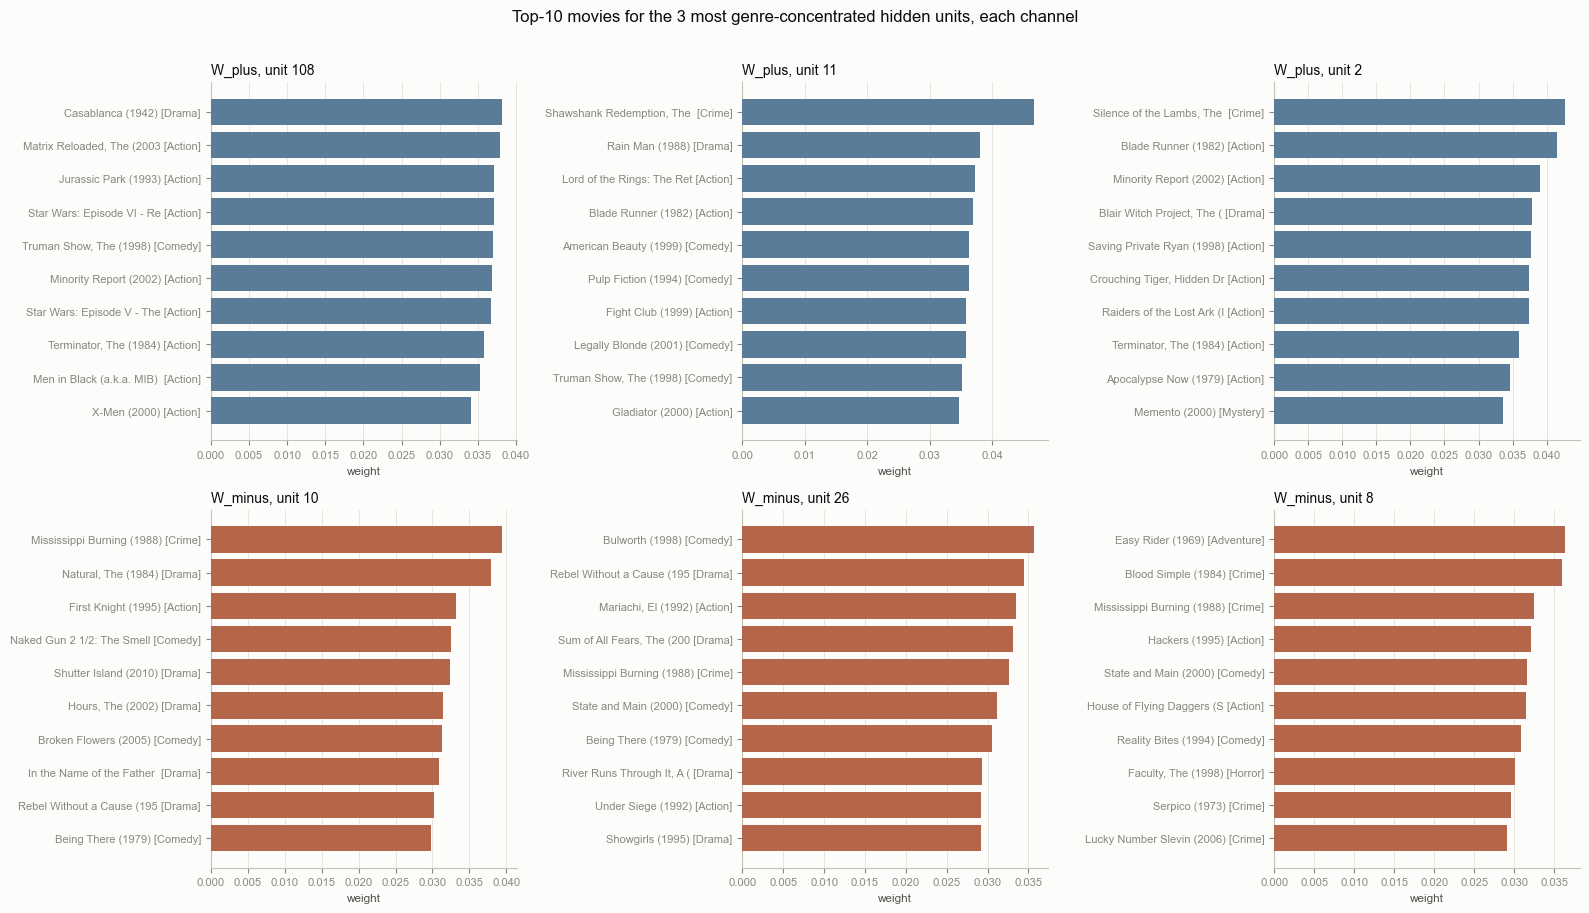

In [5]:
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=SURFACE)
panels = [("W_plus", W_plus, u, "#5b7c99") for u in plus_top3] + [("W_minus", W_minus, u, "#b4654a") for u in minus_top3]

for ax, (label, W, u, color) in zip(axes.flat, panels):
    top_df = top_movies_for_unit(W, u).iloc[::-1]
    ax.set_facecolor(SURFACE)
    bars = ax.barh(range(len(top_df)), top_df["weight"], color=color, zorder=3)
    labels = [f"{t[:26]} [{g.split('|')[0]}]" for t, g in zip(top_df["title"], top_df["genres"])]
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels(labels, fontsize=7.5)
    ax.set_title(f"{label}, unit {u}", color=INK_PRIMARY, fontsize=10, loc="left")
    ax.set_xlabel("weight", color=INK_SECONDARY, fontsize=8.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.grid(axis="x", color=GRID, linewidth=0.6, zorder=0)

fig.suptitle("Top-10 movies for the 3 most genre-concentrated hidden units, each channel", fontsize=12, color=INK_PRIMARY, y=1.01)
plt.tight_layout()
plt.savefig(out_dir / "dRBM_hidden_unit_top_movies.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

##### Figure 2: PCA of the movie embeddings, e_plus vs e_minus, colored by primary genre

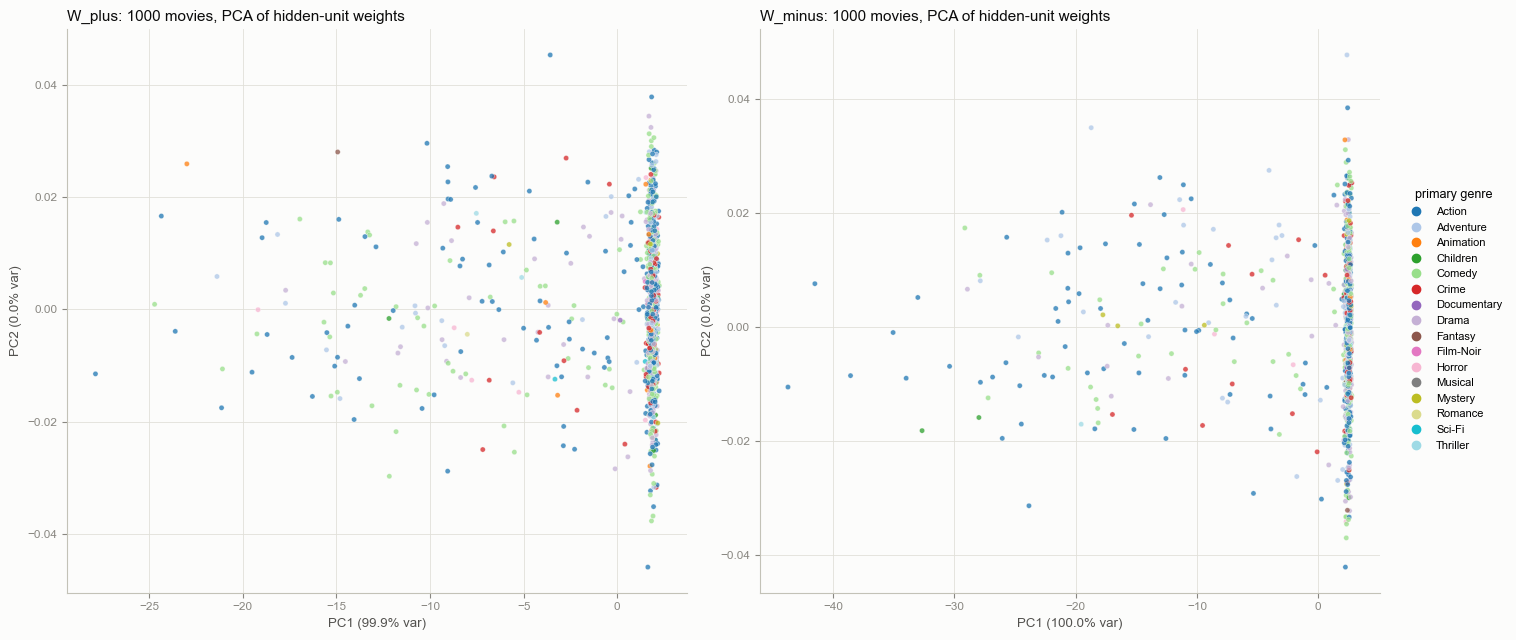

In [6]:
primary_genre = [movies_genres_map.get(mid, "(no genres listed)").split("|")[0] for mid in all_movies]
unique_genres = sorted(set(primary_genre))
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_to_color = {g: cmap(i) for i, g in enumerate(unique_genres)}
point_colors = [genre_to_color[g] for g in primary_genre]

pca_plus = PCA(n_components=2, random_state=42).fit(W_plus)
coords_plus = pca_plus.transform(W_plus)
pca_minus = PCA(n_components=2, random_state=42).fit(W_minus)
coords_minus = pca_minus.transform(W_minus)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor=SURFACE)
for ax, coords, label, pca in [(axes[0], coords_plus, "W_plus", pca_plus), (axes[1], coords_minus, "W_minus", pca_minus)]:
    ax.set_facecolor(SURFACE)
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=14, alpha=0.75, edgecolors=SURFACE, linewidths=0.3, zorder=3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)", color=INK_SECONDARY, fontsize=9.5)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)", color=INK_SECONDARY, fontsize=9.5)
    ax.set_title(f"{label}: 1000 movies, PCA of hidden-unit weights", color=INK_PRIMARY, fontsize=11, loc="left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=genre_to_color[g], markersize=6) for g in unique_genres]
fig.legend(handles, unique_genres, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False, title="primary genre", title_fontsize=9)
plt.tight_layout()
plt.savefig(out_dir / "dRBM_pca_genre_scatter.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Step 4 -- the PCA degeneracy, diagnosed and fixed

Figure 2's PCA showed PC1 explaining 99.9-100% of variance -- checked against the R baseline (`W_real.npy`, same architecture, PCA'd the same way): R's PCA gives a normal PC1=39.8% / PC2=23.0% split, so the collapse is **not** a property of the hyperbolic decomposition. It's caused by a handful of movies with pathological row norms (e.g. Speed 2: Cruise Control, norm=29.75, vs. a median row norm of 0.17 -- about 150x). Row-normalizing each movie's weight vector before PCA (direction only, magnitude divided out) removes the artifact.

In [7]:
def row_normalized_pca(W, eps=1e-8):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    W_unit = W / np.clip(norms, eps, None)
    pca = PCA(n_components=2, random_state=42).fit(W_unit)
    coords = pca.transform(W_unit)
    return coords, pca

coords_plus_norm, pca_plus_norm = row_normalized_pca(W_plus)
coords_minus_norm, pca_minus_norm = row_normalized_pca(W_minus)

print(f"row-normalized W_plus PCA:  PC1={pca_plus_norm.explained_variance_ratio_[0]:.1%}  PC2={pca_plus_norm.explained_variance_ratio_[1]:.1%}")
print(f"row-normalized W_minus PCA: PC1={pca_minus_norm.explained_variance_ratio_[0]:.1%}  PC2={pca_minus_norm.explained_variance_ratio_[1]:.1%}")

row-normalized W_plus PCA:  PC1=54.3%  PC2=0.8%
row-normalized W_minus PCA: PC1=52.2%  PC2=0.8%


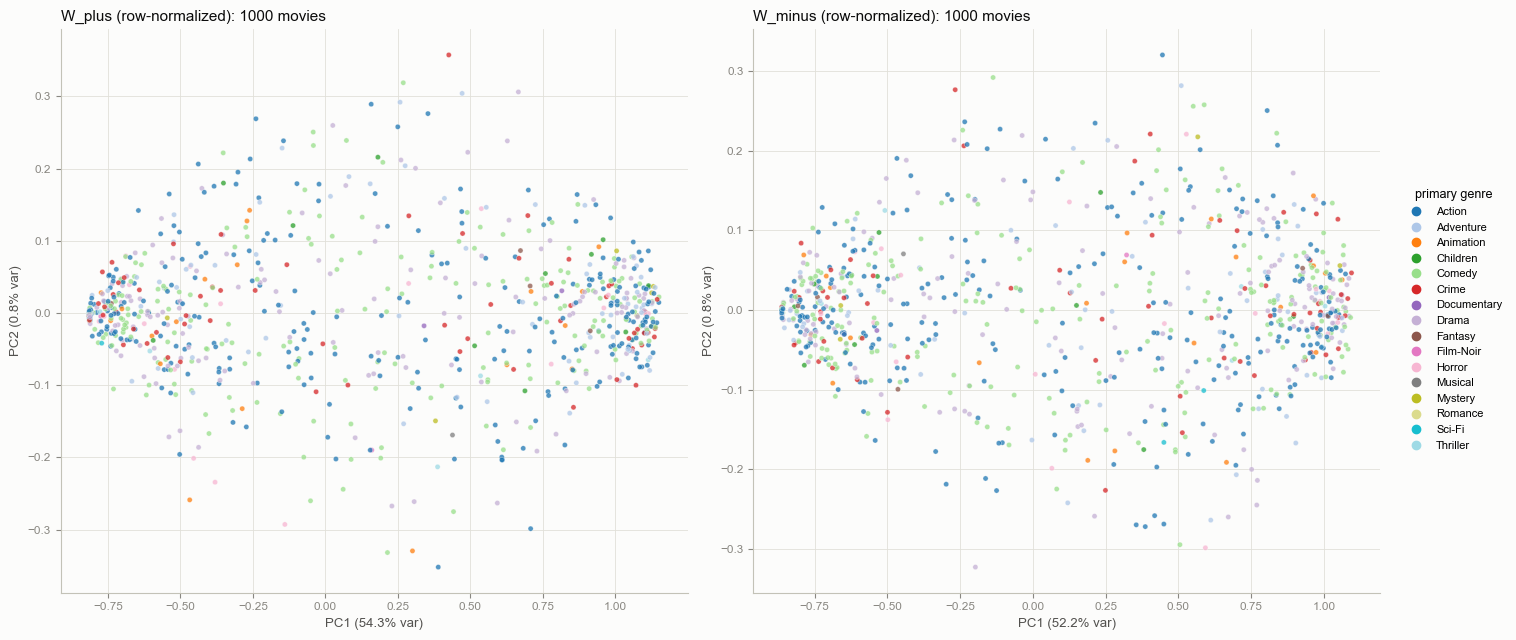

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor=SURFACE)
for ax, coords, label, pca in [(axes[0], coords_plus_norm, "W_plus (row-normalized)", pca_plus_norm),
                                  (axes[1], coords_minus_norm, "W_minus (row-normalized)", pca_minus_norm)]:
    ax.set_facecolor(SURFACE)
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=14, alpha=0.75, edgecolors=SURFACE, linewidths=0.3, zorder=3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)", color=INK_SECONDARY, fontsize=9.5)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)", color=INK_SECONDARY, fontsize=9.5)
    ax.set_title(f"{label}: 1000 movies", color=INK_PRIMARY, fontsize=11, loc="left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=genre_to_color[g], markersize=6) for g in unique_genres]
fig.legend(handles, unique_genres, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False, title="primary genre", title_fontsize=9)
plt.tight_layout()
plt.savefig(out_dir / "dRBM_pca_genre_scatter_normalized.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Step 5 -- popularity comparison chart (W_plus vs W_minus)

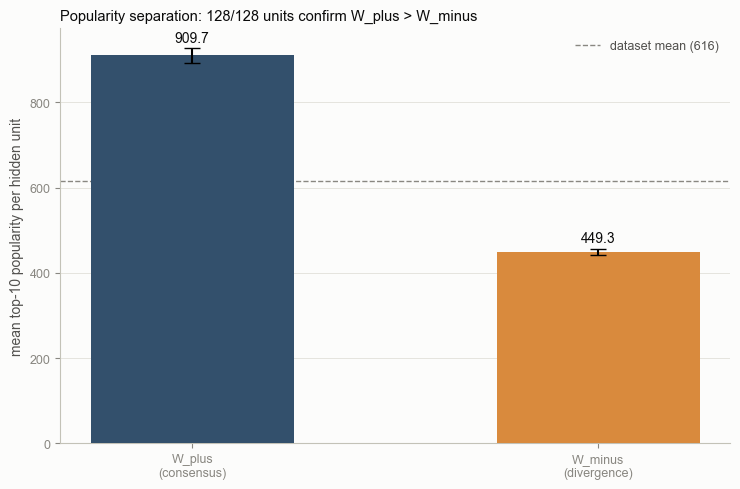

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(2)
means = [plus_pops.mean(), minus_pops.mean()]
stds = [plus_pops.std(), minus_pops.std()]
colors = ["#33506c", "#d98a3d"]
bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, width=0.5, zorder=3)
ax.axhline(movie_counts_d.mean(), color=INK_MUTED, linewidth=1, linestyle="--", zorder=2, label=f"dataset mean ({movie_counts_d.mean():.0f})")
ax.set_xticks(x)
ax.set_xticklabels(["W_plus\n(consensus)", "W_minus\n(divergence)"], fontsize=10)
ax.set_ylabel("mean top-10 popularity per hidden unit", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"Popularity separation: {int((plus_pops > minus_pops).sum())}/{W_plus.shape[1]} units confirm W_plus > W_minus", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for i, m in enumerate(means):
    ax.text(i, m + stds[i] + 15, f"{m:.1f}", ha="center", fontsize=10, color=INK_PRIMARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "dRBM_popularity_separation.png", dpi=150, facecolor=SURFACE)
plt.show()